# Topic modeling

## 0. Libraries import

In [20]:
import pandas as pd
import numpy as np
import ast
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
import string 
import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [2]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from gensim.models import CoherenceModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

## 1. Data import

In [3]:
DATA_PATH = "Kickstarter_filtered.csv"
df = pd.read_csv(DATA_PATH, index_col = 0, engine = "python")
df['lemmatized_filtered'] = df['lemmatized_filtered'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
print(df.shape)
df.head()

(7354, 14)


,title,description,pledged,goal,currency,video,category,reached,status,duration,description_processed,pos_tagged,lemmatized,lemmatized_filtered
url,,,,,,,,,,,,,,
https://www.kickstarter.com/projects/thetruthbook/the-life-network,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,1,Film & Video,148.172917,1,30,"['problem', 'much', 'entertainment', 'today', ...","[('problem', 'NN'), ('much', 'JJ'), ('entertai...","['problem', 'much', 'entertainment', 'today', ...","[problem, entertainment, today, push, unholy, ..."
https://www.kickstarter.com/projects/99625582/study-abroad-trip-of-a-lifetime,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,1,Film & Video,106.208130,1,41,"['millions', 'american', 'college', 'students'...","[('millions', 'NNS'), ('american', 'JJ'), ('co...","['million', 'american', 'college', 'student', ...","[million, american, college, student, study, a..."
https://www.kickstarter.com/projects/distortreality/cartoon-network-alphabet-pins,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,1,Film & Video,5.775000,0,45,"['full', 'set', 'launching', 'set', 'show', 'l...","[('full', 'JJ'), ('set', 'NN'), ('launching', ...","['full', 'set', 'launch', 'set', 'show', 'love...","[full, launch, early, cartoon, network, type, ..."
https://www.kickstarter.com/projects/jordym/the-balloon-a-short-film,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,15000.0,USD,1,Film & Video,34.246667,0,60,"['sleepy', 'summer', 'afternoon', 'stared', 'v...","[('sleepy', 'NN'), ('summer', 'NN'), ('afterno...","['sleepy', 'summer', 'afternoon', 'star', 'voi...","[sleepy, summer, afternoon, star, void, float,..."
https://www.kickstarter.com/projects/trans-movie/something-you-should-know-about-me-a-feature-film,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50000.0,USD,1,Film & Video,101.280000,1,30,"['hours', 'pledge', 'matching', 'amazing', 'ne...","[('hours', 'NNS'), ('pledge', 'VBP'), ('matchi...","['hour', 'pledge', 'match', 'amaze', 'news', '...","[hour, pledge, match, amaze, news, generous, b..."


## 2. Latent Dirichlet Analysis (LDA) for Film & Video category

### 2.1 Bag of Words creation

Topic modeling has been performed only on the *Film & Video* category rather than on the entire dataset, as this category contains the largest number of documents and words among others, resulting in a richer and more representative vocabulary. Moreover, running the model on the full corpus was tested, however, the dominant structure that emerged was the separation between categories, meaning that the topics largely reflected the original labels instead of uncovering latent themes. As a matter of fact, differences in vocabulary across categories are stronger than the internal thematic variation within them, therefore, by restricting the analysis to a single category, the model should be able to focus on more specific patterns.

In [4]:
# Considering the entire corpus
texts_all = df['lemmatized_filtered'].tolist()
dictionary_all = Dictionary(texts_all)
corpus_all = [dictionary_all.doc2bow(text) for text in texts_all]

print("Number of words in global dictionary:", len(dictionary_all))
print("Number of documents:", len(corpus_all))

# Filtering for Film & Video category
df_film = df[df['category'] == 'Film & Video']
texts_film = df_film['lemmatized_filtered'].tolist()
dictionary_film = Dictionary(texts_film)
corpus_film = [dictionary_film.doc2bow(text) for text in texts_film]

print("Number of words in the dictionary:", len(dictionary_film))
print("Number of documents:", len(corpus_film))

Number of words in global dictionary: 22611
Number of documents: 7354
Number of words in the dictionary: 18566
Number of documents: 2011


### 2.2 Coherence scores

#### Coherence scores computation

Coherence scores are used to guide the choice of the number of topics, since in LDA this parameter has to be set manually and there is no predefined correct value. Therefore, different number of topics (k) are tested and for each one the coherence is computed in order to evaluate how meaningful the resulting topics are. Moreover, to avoid relying on a single measure, the comparisono between the different values is done across multiple metrics (U_Mass, C_V and NPMI). However, looking at the results, k = 3 provides the best overall values, even if the differences with the other configurations are relatively small, meaning that the improvement is not strong but still consistent across the metrics and, for this reason, three topics has been selected as a reasonable choice.

In [5]:
topic_range = range(2, 6)

coherence_values = []
lda_models = []

for k in topic_range:
    lda_model = LdaMulticore(
        corpus = corpus_film,
        id2word = dictionary_film,
        num_topics = k,
        passes = 10,
        workers = 2,
        random_state = 11
    )

    # Coherence UMass
    coherence_umass = CoherenceModel(
        model = lda_model,
        corpus = corpus_film,
        dictionary = dictionary_film,
        coherence = 'u_mass'
    ).get_coherence()

    # Coherence C_V
    coherence_cv = CoherenceModel(
        model = lda_model,
        texts = texts_film,
        dictionary = dictionary_film,
        coherence = 'c_v'
    ).get_coherence()

    # Coherence NPMI
    coherence_npmi = CoherenceModel(
        model = lda_model,
        texts = texts_film,
        dictionary = dictionary_film,
        coherence = 'c_npmi'
    ).get_coherence()

    coherence_values.append((k, coherence_umass, coherence_cv, coherence_npmi))
    lda_models.append(lda_model)

    print(f"k = {k} | UMass = {coherence_umass:.4f} | C_V = {coherence_cv:.4f} | NPMI = {coherence_npmi:.4f}")

k = 2 | UMass = -0.7794 | C_V = 0.3571 | NPMI = 0.0009
k = 3 | UMass = -0.8309 | C_V = 0.3654 | NPMI = 0.0068
k = 4 | UMass = -0.8283 | C_V = 0.3616 | NPMI = 0.0039
k = 5 | UMass = -0.8759 | C_V = 0.3474 | NPMI = 0.0032


#### Coherence scores visualization

The three plots confirm that the coherence scores are similar across all configurations, with only small variations as the number of topics changes. Indeed, both C_V and NPMI show a slight peak at k = 3, suggesting a marginal improvement in topic quality for this choice. However, UMass, on the other hand, is slightly better at k = 2, although the difference is limited and does not indicate a strong preference.

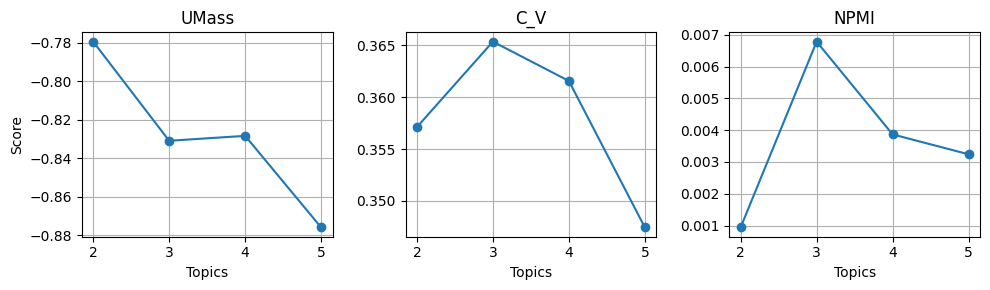

In [6]:
scores = pd.DataFrame(
    coherence_values,
    columns = ["num_topics", "u_mass", "c_v", "npmi"]
)

fig, axes = plt.subplots(1, 3, figsize = (10, 3))

# UMass
axes[0].plot(scores["num_topics"], scores["u_mass"], marker = "o")
axes[0].set_title("UMass")
axes[0].set_xlabel("Topics")
axes[0].set_ylabel("Score")
axes[0].grid(True)

# C_V
axes[1].plot(scores["num_topics"], scores["c_v"], marker = "o")
axes[1].set_title("C_V")
axes[1].set_xlabel("Topics")
axes[1].grid(True)

# NPMI
axes[2].plot(scores["num_topics"], scores["npmi"], marker = "o")
axes[2].set_title("NPMI")
axes[2].set_xlabel("Topics")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 2.3 Identification of the main topics

#### Latent Dirichlet Allocation (LDA)

After selecting the number of topics, the LDA model has been applied to the *Film & Video* corpus to identify the main topics based on word co-occurrence patterns. In practice, the model groups together words that frequently appear in the same documents, assuming that they are likely to belong to the same underlying theme. Therefore, once the model has been trained, the top 20 words for each topic are listed, meaning that the words that most frequently co-occur within the same context are gathered, defining each topic.

In [7]:
num_topics = 3

model_film = LdaMulticore(
    corpus=  corpus_film,
    id2word = dictionary_film,
    num_topics = num_topics,
    passes = 10,
    workers = 2,
    random_state = 11
)

topic_corpus_film = model_film[corpus_film]

print("\nTopic distribution of the first Film & Video document:")
print(topic_corpus_film[0])

print("\nTop 20 words for each topic in 'Film & Video':")
for i, topic in model_film.print_topics(num_words = 20):
    print(f"\nTopic {i}:")
    print(topic)


Topic distribution of the first Film & Video document:
[(0, np.float32(0.13480599)), (1, np.float32(0.037329577)), (2, np.float32(0.82786447))]

Top 20 words for each topic in 'Film & Video':

Topic 0:
0.025*"film" + 0.004*"director" + 0.004*"short" + 0.004*"festival" + 0.004*"producer" + 0.003*"art" + 0.003*"family" + 0.003*"community" + 0.003*"documentary" + 0.003*"crew" + 0.002*"filmmaker" + 0.002*"produce" + 0.002*"award" + 0.002*"cast" + 0.002*"tell" + 0.002*"school" + 0.002*"day" + 0.002*"woman" + 0.002*"black" + 0.002*"artist"

Topic 1:
0.026*"film" + 0.006*"movie" + 0.005*"festival" + 0.004*"short" + 0.003*"producer" + 0.003*"director" + 0.003*"art" + 0.003*"cast" + 0.003*"write" + 0.003*"music" + 0.002*"crew" + 0.002*"video" + 0.002*"day" + 0.002*"produce" + 0.002*"character" + 0.002*"great" + 0.002*"series" + 0.002*"right" + 0.002*"actor" + 0.002*"thing"

Topic 2:
0.013*"film" + 0.006*"episode" + 0.005*"series" + 0.004*"character" + 0.004*"music" + 0.004*"sound" + 0.004*"ani

#### Interpretation of topic descriptions

The topic descriptions are further processed to extract more readable lists of keywords for each topic, simplifying the interpretation. From the extracted keywords, it can be observed that the topics share several common terms (e.g. *film*, *director*, *producer*, *festival*), indicating that they are not sharply separated, however, this was expected, as all documents belong to the same category and therefore cover related content. Despite this overlap, some differences can still be noticed, for example, Topic 0 is more focused on terms related to production (e.g. *director*, *producer*, *crew*, *filmmaker*, *cast*), while Topic 2 includes more elements related to content and format (e.g. *series*, *episode*, *character*, *animation*).

In [8]:
topic_sep = re.compile(r"0\.[0-9]{3}\*")

model_topics = [
    (topic_no, re.sub(topic_sep, "", model_topic).split(' + '))
    for topic_no, model_topic in model_film.print_topics(num_topics = num_topics, num_words = 20)
]

descriptors = []

print("Readable topic descriptors:\n")
for i, words in model_topics:
    clean_words = [w.replace('"', '').strip() for w in words]
    print(f"Topic {i}: {', '.join(clean_words)}")
    descriptors.append(", ".join(clean_words[:6]))

print("\nShort descriptors list:")
print(descriptors)

Readable topic descriptors:

Topic 0: film, director, short, festival, producer, art, family, community, documentary, crew, filmmaker, produce, award, cast, tell, school, day, woman, black, artist
Topic 1: film, movie, festival, short, producer, director, art, cast, write, music, crew, video, day, produce, character, great, series, right, actor, thing
Topic 2: film, episode, series, character, music, sound, animation, video, artist, director, season, crew, cast, budget, actor, producer, produce, pilot, voice, art

Short descriptors list:
['film, director, short, festival, producer, art', 'film, movie, festival, short, producer, director', 'film, episode, series, character, music, sound']


#### Topic quality measurement

Topic diversity is computed to evaluate how different the topics are from each other, by measuring the proportion of unique words across the top terms of each topic. In this case, the results show that around 62% of the words are unique, meaning that a significant portion of words is not shared across different topics. However, on the other hand, around 38% of top 20 words is in common, indicating that the topics are not highly distinct and tend to partially overlap, which is consistent with the previous observations. 


In [9]:
num_words = 20

topic_words = [
    re.sub(topic_sep, "", model_topic).split(' + ')
    for topic_no, model_topic in model_film.print_topics(
        num_topics = num_topics,
        num_words = num_words
    )
]

topic_words = [
    [w.replace('"', '').strip() for w in topic]
    for topic in topic_words
]

unique_words = set()
for topic in topic_words:
    unique_words.update(topic[:num_words])

td = len(unique_words) / (num_words * len(topic_words))

print(
    f"Topic Diversity (top-{num_words} words): {td:.4f} "
    f"[unique words = {len(unique_words)}, total words = {num_words * len(topic_words)}]"
)

Topic Diversity (top-20 words): 0.6167 [unique words = 37, total words = 60]


#### LDA topic visualization (pyLDAvis)

The pyLDAvis visualization shows that the topics are clearly separated in the 2D projection, indicating that the model captures distinct thematic structures. However, despite this apparent separation, previous analyses revealed that the topics still share several common terms and exhibit only moderate diversity. This suggests that the topics are distinguishable at a global level but not strongly differentiated in terms of their semantic content.

In [26]:
lda_vis = gensimvis.prepare(
    model_film,
    corpus_film,
    dictionary_film
)
pyLDAvis.display(lda_vis)

### 2.4 Topic analysis across documents

#### Topic distribution and dominant topic assignment

The table provides a document level representation of the topic model, where each document is described by the probability of belonging to each topic and by its dominant topic, making it possible to directly compare documents and observe how strongly they are associated with different topics. From these values, it can be seen that many documents are clearly dominated by a single topic with high probability, while others show a more mixed distribution. 

In [10]:
topic_rows = []

# Topic probabilities and dominant topic assignment
for doc_id, doc_topics in enumerate(topic_corpus_film):
    row = {"doc_id": doc_id}
    for i in range(num_topics):
        row[f"topic_{i}_prob"] = 0
    for topic_id, prob in doc_topics:
        row[f"topic_{topic_id}_prob"] = prob
    dominant_topic = max(doc_topics, key = lambda x: x[1])
    row["dominant_topic"] = dominant_topic[0]
    topic_rows.append(row)
topic_table = pd.DataFrame(topic_rows)

topic_labels = {i: descriptors[i] for i in range(len(descriptors))}
topic_table["dominant_topic_label"] = topic_table["dominant_topic"].map(topic_labels)
df_film_clean = df[df["category"] == "Film & Video"].copy().reset_index(drop = True)
topic_table["status"] = df_film_clean["status"].values

if "name" in df_film_clean.columns:
    topic_table.insert(1, "document", df_film_clean["name"].values)
elif "blurb" in df_film_clean.columns:
    topic_table.insert(1, "document", df_film_clean["blurb"].values)

topic_prob_cols = [f"topic_{i}_prob" for i in range(num_topics)]

topic_table = topic_table[
    ["doc_id"] +
    (["document"] if "document" in topic_table.columns else []) +
    topic_prob_cols +
    ["dominant_topic", "dominant_topic_label", "status"]
]

# Renaming columns
rename_dict = {
    "doc_id": "Doc ID",
    "dominant_topic": "Dominant Topic",
    "dominant_topic_label": "Dominant Topic Description",
    "status": "Project Status"
}
for i in range(num_topics):
    rename_dict[f"topic_{i}_prob"] = f"Topic {i} Probability"
topic_table = topic_table.rename(columns = rename_dict)

topic_table.head(10)

,Doc ID,Topic 0 Probability,Topic 1 Probability,Topic 2 Probability,Dominant Topic,Dominant Topic Description,Project Status
0,0,0.133357,0.038438,0.828205,2,"film, episode, series, character, music, sound",1
1,1,0.935508,0.063075,0.000000,0,"film, director, short, festival, producer, art",1
2,2,0.000000,0.906512,0.091687,1,"film, movie, festival, short, producer, director",0
3,3,0.997890,0.000000,0.000000,0,"film, director, short, festival, producer, art",0
4,4,0.644082,0.232328,0.123589,0,"film, director, short, festival, producer, art",1
5,5,0.889035,0.109270,0.000000,0,"film, director, short, festival, producer, art",0
6,6,0.000000,0.379809,0.617232,2,"film, episode, series, character, music, sound",1
7,7,0.000000,0.992699,0.000000,1,"film, movie, festival, short, producer, director",0
8,8,0.000000,0.994871,0.000000,1,"film, movie, festival, short, producer, director",1
9,9,0.000000,0.000000,0.996175,2,"film, episode, series, character, music, sound",1


#### Identification of representative documents per topic

The table reports the most representative documents for each topic, identified as those with the highest probability values, indeed, these documents can be considered the most pure examples of each topic, as they are strongly associated with a single theme. As shown in the results, the selected documents have very high probabilities (close to 1), indicating that they are clearly dominated by one topic. 

In [11]:
rows = []
n_top = 3

for topic_id in range(num_topics):
    col = f"Topic {topic_id} Probability"
    
    top_docs = topic_table.sort_values(by = col, ascending = False).head(n_top)
    
    for _, row in top_docs.iterrows():
        rows.append({
            "Topic": topic_id,
            "Topic Description": topic_labels[topic_id],
            "Doc ID": row["Doc ID"],
            "Probability": round(row[col], 3)
        })

top_docs_table = pd.DataFrame(rows)
top_docs_table

,Topic,Topic Description,Doc ID,Probability
0,0,"film, director, short, festival, producer, art",1357,0.999
1,0,"film, director, short, festival, producer, art",663,0.999
2,0,"film, director, short, festival, producer, art",1691,0.999
3,1,"film, movie, festival, short, producer, director",1159,0.999
4,1,"film, movie, festival, short, producer, director",455,0.999
5,1,"film, movie, festival, short, producer, director",1017,0.999
6,2,"film, episode, series, character, music, sound",684,1.000
7,2,"film, episode, series, character, music, sound",1798,1.000
8,2,"film, episode, series, character, music, sound",1989,1.000


#### Project success across topics

The table shows how projects are distributed across topics and how each topic relates to project success, indeed, for each dominant topic, the number of successful and failed projects is reported, allowing a direct comparison. Overall, the differences between topics are relatively small, with similar proportions of successful and failed projects, suggesting that, within this category, the identified topics do not have a strong impact on project success, although slight variations can still be observed.

In [12]:
topic_success = (
    topic_table
    .groupby(["Dominant Topic", "Project Status"])
    .size()
    .unstack(fill_value = 0)
)

topic_success = topic_success.rename(columns = {
    0: "Failed",
    1: "Successful"
})

topic_success["Total Documents"] = topic_success["Failed"] + topic_success["Successful"]
topic_success = topic_success.reset_index()
topic_success["Topic Description"] = topic_success["Dominant Topic"].map(topic_labels)
topic_success = topic_success[
    ["Dominant Topic", "Topic Description", "Total Documents", "Successful", "Failed"]
]
topic_success["Success Rate"] = (topic_success["Successful"] / topic_success["Total Documents"]).round(3)
topic_success.index.name = None
topic_success.columns.name = None

topic_success

,Dominant Topic,Topic Description,Total Documents,Successful,Failed,Success Rate
0,0,"film, director, short, festival, producer, art",793,528,265,0.666
1,1,"film, movie, festival, short, producer, director",780,494,286,0.633
2,2,"film, episode, series, character, music, sound",438,247,191,0.564


### 2.5 Logistic regression

#### Logistic regression with topic features only

The logistic regression model based only on topic probabilities shows limited predictive performance, in fact, the accuracy is around 0.52, which is only slightly above random guessing, while the F1-score (0.629) reflects a moderate balance between precision and recall. Overall, the model is able to capture some signal, but the predictive power remains weak, suggesting that topic distributions alone do not provide enough information to reliably distinguish between successful and failed projects.

In [ ]:
# Features
X_topics = topic_table[[f"Topic {i} Probability" for i in range(num_topics)]]
# Target
y = topic_table["Project Status"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_topics,
    y,
    test_size = 0.3,
    random_state = 11,
    stratify = y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression model
log_model_topics = LogisticRegression(max_iter = 1000, class_weight = "balanced")
log_model_topics.fit(X_train_scaled, y_train)

# Predictions
y_pred_topics = log_model_topics.predict(X_test_scaled)

performance_topics = pd.DataFrame({
    "Model": ["Topics only"],
    "Accuracy": [accuracy_score(y_test, y_pred_topics)],
    "Precision": [precision_score(y_test, y_pred_topics)],
    "Recall": [recall_score(y_test, y_pred_topics)],
    "F1-score": [f1_score(y_test, y_pred_topics)]
}).round(3)

performance_topics

,Model,Accuracy,Precision,Recall,F1-score
0,Topics only,0.578,0.652,0.709,0.679


The coefficients indicate the direction and relative importance of each topic in predicting project success. Topic 0 has a small positive coefficient, suggesting a weak association with higher success probability, while Topic 1 has a very limited positive effect. On the other hand, Topic 2 shows a negative coefficient, indicating a slight tendency to be associated with unsuccessful projects. However, all coefficients are relatively small in magnitude, confirming that the influence of topics on project success is limited and reinforcing the idea that textual themes alone are not strong predictors of success.

In [14]:
coefficients_topics = pd.DataFrame({
    "Feature": X_topics.columns,
    "Coefficient": log_model_topics.coef_[0]
}).sort_values(by = "Coefficient", ascending = False).round(3)

coefficients_topics

,Feature,Coefficient
0,Topic 0 Probability,0.325
1,Topic 1 Probability,0.279
2,Topic 2 Probability,0.078


#### Logistic regression with topic and campaign features

The extended logistic regression model includes both topic probabilities and 2 variables related to the campaigns, funding goal and campaign duration (the funding goal is transformed using a logarithmic scale to reduce the strong skewness of its distribution and limit the impact of extreme values). Compared to the model based only on topics, the performance improves only slightly, with an accuracy of 0.588 and an F1-score of 0.647, indicating that more structural campaign features provides some additional information, but the overall predictive power remains limited.

In [15]:
# Features
X_extended = topic_table[[f"Topic {i} Probability" for i in range(num_topics)]].copy()
df_film_clean = df[df["category"] == "Film & Video"].copy().reset_index(drop = True)
X_extended["log_goal"] = np.log1p(df_film_clean["goal"])
X_extended["duration"] = df_film_clean["duration"]
# Target
y = topic_table["Project Status"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_extended,
    y,
    test_size = 0.3,
    random_state = 11,
    stratify = y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression model
log_model_extended = LogisticRegression(max_iter = 1000, class_weight = "balanced")
log_model_extended.fit(X_train_scaled, y_train)

# Predictions
y_pred_extended = log_model_extended.predict(X_test_scaled)

# Performance table
performance_extended = pd.DataFrame({
    "Model": ["Topics + campaign variables"],
    "Accuracy": [accuracy_score(y_test, y_pred_extended)],
    "Precision": [precision_score(y_test, y_pred_extended)],
    "Recall": [recall_score(y_test, y_pred_extended)],
    "F1-score": [f1_score(y_test, y_pred_extended)]
}).round(3)

performance_extended

,Model,Accuracy,Precision,Recall,F1-score
0,Topics + campaign variables,0.588,0.704,0.598,0.647


The coefficients show that topic probabilities have a weak positive association with project success, while log_goal and duration have negative coefficients. This suggests that projects with higher funding goals and longer campaign durations are less likely to be successful. However, since the overall performance of the model is still modest, these results should be interpreted cautiously. Overall, the regression confirms that project success cannot be explained well by topic composition alone and even the additional campaign variables considered here are not sufficient to build a strong predictive model.

In [16]:
coefficients_extended = pd.DataFrame({
    "Feature": X_extended.columns,
    "Coefficient": log_model_extended.coef_[0]
}).sort_values(by = "Coefficient", ascending = False).round(3)

coefficients_extended

,Feature,Coefficient
0,Topic 0 Probability,0.304
1,Topic 1 Probability,0.273
2,Topic 2 Probability,0.081
3,log_goal,-0.175
4,duration,-0.305
